# Scalar Tikhonov baseline

This notebook selects one scalar regularisation parameter on the same fixed
SeaTurtle validation split used by the learned models. It performs a coarse
search, a local refined search, and a fixed-CG iteration study. The final
summary is saved in the exact format used by the subsequent notebooks.


This cell locates the cleaned pipeline from the current working directory, changes into it, and adds it to Python's import path so local modules resolve consistently.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def locate_project_root() -> Path:
    """Find cleaned_pipeline regardless of where Jupyter was launched."""
    cwd = Path.cwd().resolve()
    candidates = []
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "cleaned_pipeline"))
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find cleaned_pipeline. Start Jupyter from Thesis/Python, "
        "cleaned_pipeline, or cleaned_pipeline/notebooks."
    )


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline


## Imports

In [2]:
from argparse import Namespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.evaluation.tikhonov_eval import (
    evaluate_scalar_tikhonov_grid,
    scalar_tikhonov_denoise,
)
from src.models.cg_tikhonov import scalar_tikhonov_operator
from src.solvers.conjugate_gradient import cg_solve_fixed_iters
from src.training.denoising import build_seaturtle_loaders, get_device
from src.utils.metrics import batch_mse, batch_psnr, batch_ssim

device = get_device()
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.12.0
Device: mps


## Shared SeaTurtle validation data
`SEA_TURTLE_ROOT` is the only machine-specific path in this notebook. Edit this value to your own Kaggle cache version changes.
This cell collects the dataset, architecture, solver, optimisation, noise, seed, and output settings into the namespace consumed by the training pipeline.

In [3]:
SEA_TURTLE_ROOT = Path(
    "/Users/kyrillguba/.cache/kagglehub/datasets/"
    "wildlifedatasets/seaturtleid2022/versions/4"
).expanduser()

if not SEA_TURTLE_ROOT.is_dir():
    raise FileNotFoundError(
        f"SeaTurtle root not found: {SEA_TURTLE_ROOT}. "
        "Edit SEA_TURTLE_ROOT before continuing."
    )

args = Namespace(
    data_root=str(SEA_TURTLE_ROOT),
    checkpoint_dir=str(PROJECT_ROOT / "checkpoints" / "scalar_tikhonov"),
    image_size=256,
    max_images=550,
    val_images=50,
    sigma_min=0.0,
    sigma_max=0.2,
    val_sigma=0.1,
    val_noise_seed=10_000,
    base_channels=32,
    depth=3,
    epochs=20,
    batch_size=1,
    lr=1e-4,
    weight_decay=1e-5,
    grad_clip=1.0,
    num_workers=0,
    print_every=50,
    seed=42,
    device=None,
    clamp_for_metrics=True,
)

_, val_loader = build_seaturtle_loaders(args)
sample_a = val_loader.dataset[0]
sample_b = val_loader.dataset[0]
assert torch.equal(sample_a["noisy"], sample_b["noisy"])
print("Validation images:", len(val_loader.dataset))
print("Validation sigma:", float(sample_a["sigma"].item()))


Validation images: 50
Validation sigma: 0.10000000149011612


## Coarse and refined lambda search

`sigma=None` is deliberate: the evaluator uses the already deterministic noisy
tensors supplied by the shared validation loader instead of generating a second
corruption.


In [4]:
CG_MAX_ITER = 100
CG_TOL = 1e-6
coarse_lambdas = [
    1e-4, 3e-4, 1e-3, 3e-3, 1e-2,
    3e-2, 1e-1, 3e-1, 1.0, 3.0,
]

coarse_results = evaluate_scalar_tikhonov_grid(
    loader=val_loader,
    lambdas=coarse_lambdas,
    sigma=None,
    device=device,
    max_iter=CG_MAX_ITER,
    tol=CG_TOL,
    clamp_for_metrics=True,
)

results_dir = PROJECT_ROOT / "results" / "tikhonov"
results_dir.mkdir(parents=True, exist_ok=True)
coarse_results.to_csv(results_dir / "scalar_tikhonov_coarse_grid.csv", index=False)
display(coarse_results)


,lambda,mse,psnr,ssim,avg_cg_iters,min_cg_iters,max_cg_iters,mean_final_rel_residual,avg_runtime_sec
0,3.0000,0.001132,29.980802,0.795544,31.82,30,33,2.157401e-06,0.101360
1,1.0000,0.001302,28.957330,0.700239,18.30,17,19,8.995333e-07,0.058693
2,0.3000,0.002781,25.561630,0.530623,10.08,10,11,6.189037e-07,0.036488
3,0.1000,0.005326,22.738532,0.414917,6.00,6,6,5.522859e-07,0.023026
4,0.0300,0.007813,21.075319,0.354159,4.00,4,4,1.807914e-07,0.017631
5,0.0100,0.008981,20.470165,0.333400,3.00,3,3,7.814425e-08,0.013671
6,0.0030,0.009472,20.239085,0.325664,2.00,2,2,9.494435e-08,0.010702
7,0.0010,0.009622,20.170979,0.323405,1.96,1,2,8.583519e-08,0.010454
8,0.0003,0.009675,20.146913,0.322609,1.00,1,1,1.617861e-07,0.007375
9,0.0001,0.009690,20.140016,0.322381,1.00,1,1,4.658851e-08,0.009928


This cell constructs a denser grid around the best coarse value, evaluates it, selects the minimum-MSE lambda, and saves the refined table.

In [5]:
best_coarse_lambda = float(coarse_results.iloc[0]["lambda"])
coarse_array = np.asarray(sorted(coarse_lambdas), dtype=float)
best_position = int(np.where(coarse_array == best_coarse_lambda)[0][0])
lower = coarse_array[max(best_position - 1, 0)]
upper = coarse_array[min(best_position + 1, len(coarse_array) - 1)]
if lower == upper:
    lower, upper = best_coarse_lambda / 3.0, best_coarse_lambda * 3.0

refined_lambdas = np.logspace(np.log10(lower), np.log10(upper), num=13)
refined_lambdas = sorted(set(float(value) for value in refined_lambdas))

refined_results = evaluate_scalar_tikhonov_grid(
    loader=val_loader,
    lambdas=refined_lambdas,
    sigma=None,
    device=device,
    max_iter=CG_MAX_ITER,
    tol=CG_TOL,
    clamp_for_metrics=True,
)
refined_results.to_csv(
    results_dir / "scalar_tikhonov_refined_grid.csv", index=False
)
best_refined = refined_results.iloc[0]
best_lambda = float(best_refined["lambda"])

print("Refinement interval:", lower, "to", upper)
print("Best scalar lambda:", best_lambda)
display(refined_results)


Refinement interval: 1.0 to 3.0
Best scalar lambda: 2.080083823051904


,lambda,mse,psnr,ssim,avg_cg_iters,min_cg_iters,max_cg_iters,mean_final_rel_residual,avg_runtime_sec
0,2.080084,0.001103,29.932832,0.775427,26.44,25,28,1.511358e-06,0.081186
1,2.279507,0.001103,29.970345,0.781611,27.54,26,29,1.671816e-06,0.084473
2,1.898107,0.001107,29.877033,0.768475,25.28,24,26,1.393104e-06,0.077508
3,2.498050,0.001109,29.990268,0.787022,29.12,28,30,1.781620e-06,0.089345
4,1.732051,0.001116,29.802425,0.760765,24.14,23,25,1.293615e-06,0.075009
5,2.737544,0.001118,29.993438,0.791663,30.42,29,32,1.956418e-06,0.092700
6,1.580522,0.001131,29.708678,0.752318,23.02,22,24,1.213177e-06,0.071314
7,3.000000,0.001132,29.980802,0.795544,31.82,30,33,2.157401e-06,0.097271
8,1.442250,0.001152,29.595682,0.743160,21.96,21,23,1.141539e-06,0.068267
9,1.316074,0.001179,29.463564,0.733326,20.96,20,22,1.077203e-06,0.067200


## Scalar-lambda calibration curves

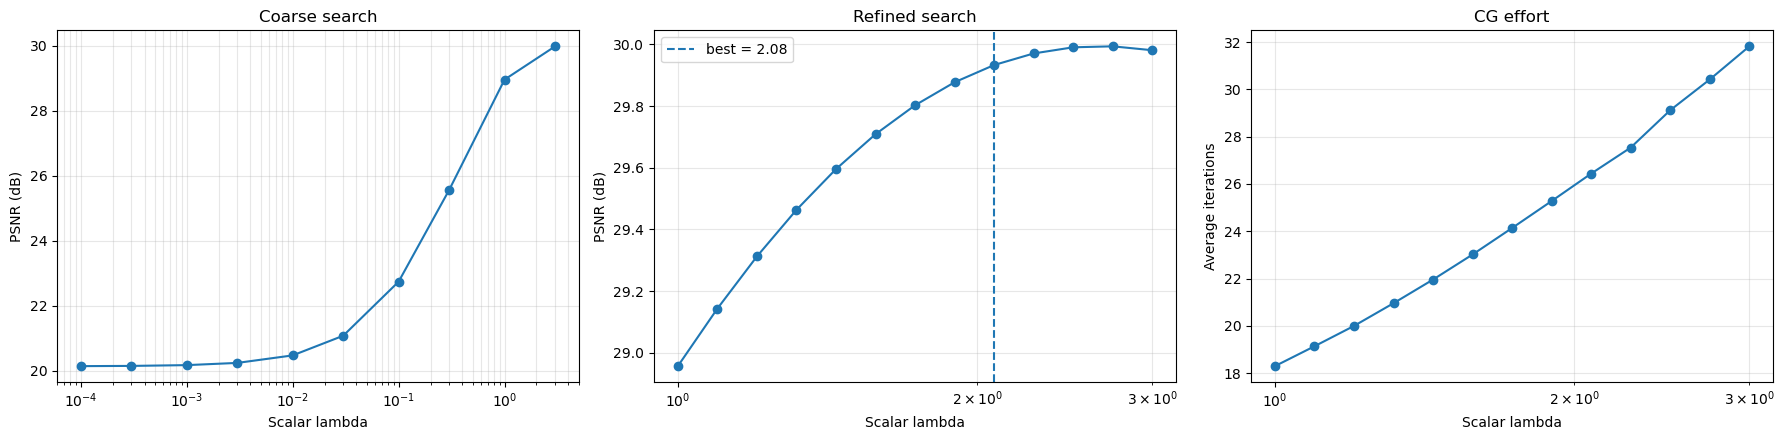

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
ordered_coarse = coarse_results.sort_values("lambda")
ordered_refined = refined_results.sort_values("lambda")

axes[0].semilogx(ordered_coarse["lambda"], ordered_coarse["psnr"], marker="o")
axes[0].set(title="Coarse search", xlabel="Scalar lambda", ylabel="PSNR (dB)")

axes[1].semilogx(ordered_refined["lambda"], ordered_refined["psnr"], marker="o")
axes[1].axvline(best_lambda, linestyle="--", label=f"best = {best_lambda:.4g}")
axes[1].set(title="Refined search", xlabel="Scalar lambda", ylabel="PSNR (dB)")
axes[1].legend()

axes[2].semilogx(
    ordered_refined["lambda"], ordered_refined["avg_cg_iters"], marker="o"
)
axes[2].set(title="CG effort", xlabel="Scalar lambda", ylabel="Average iterations")

for axis in axes:
    axis.grid(True, which="both", alpha=0.3)
fig.tight_layout()
grid_figure_path = results_dir / "scalar_tikhonov_grid_search.png"
fig.savefig(grid_figure_path, dpi=300, bbox_inches="tight")
plt.show()


## Fixed-CG iteration study


These cells compare several truncated conjugate-gradient depths with a tightly converged scalar-Tikhonov solution, record residual and solution errors, apply residual and solution-error thresholds to the fixed-depth study and write the recommended CG depth and calibrated scalar lambda.

In [7]:
@torch.no_grad()
def compare_fixed_cg_to_converged(
    loader,
    lam,
    iteration_counts=(4, 8, 16, 32, 64),
):
    rows = []
    for batch_index, batch in enumerate(loader):
        noisy = batch["noisy"].to(device)
        converged, info = scalar_tikhonov_denoise(
            noisy,
            lam=lam,
            max_iter=200,
            tol=1e-10,
        )

        def operator(image):
            return scalar_tikhonov_operator(image, lam)

        converged_norm = torch.linalg.vector_norm(converged).clamp_min(1e-12)
        noisy_norm = torch.linalg.vector_norm(noisy).clamp_min(1e-12)
        for num_iters in iteration_counts:
            fixed = cg_solve_fixed_iters(
                A=operator,
                b=noisy,
                x0=noisy,
                num_iters=num_iters,
                relative_tol=1e-12,
                check_spd=True,
            )
            rows.append(
                {
                    "image_index": batch_index,
                    "num_iters": num_iters,
                    "relative_solution_error": float(
                        (torch.linalg.vector_norm(fixed - converged) / converged_norm).item()
                    ),
                    "relative_residual": float(
                        (torch.linalg.vector_norm(operator(fixed) - noisy) / noisy_norm).item()
                    ),
                    "converged_cg_iters": info["num_iter"],
                }
            )
    return pd.DataFrame(rows)


cg_comparison = compare_fixed_cg_to_converged(val_loader, best_lambda)
cg_summary = (
    cg_comparison.groupby("num_iters", as_index=False)
    .agg(
        mean_relative_solution_error=("relative_solution_error", "mean"),
        max_relative_solution_error=("relative_solution_error", "max"),
        mean_relative_residual=("relative_residual", "mean"),
        max_relative_residual=("relative_residual", "max"),
        mean_converged_cg_iters=("converged_cg_iters", "mean"),
    )
)
cg_summary.to_csv(
    results_dir / "scalar_tikhonov_cg_iteration_study.csv", index=False
)
display(cg_summary)


,num_iters,mean_relative_solution_error,max_relative_solution_error,mean_relative_residual,max_relative_residual,mean_converged_cg_iters
0,4,1.655415e-02,2.882159e-02,0.054014,0.088837,61.48
1,8,2.375442e-03,4.145375e-03,0.006598,0.010980,61.48
2,16,4.801243e-05,8.329441e-05,0.000130,0.000218,61.48
3,32,6.696003e-09,2.160992e-08,0.000001,0.000002,61.48
4,64,0.000000e+00,0.000000e+00,0.000001,0.000002,61.48


In [8]:
solution_error_threshold = 1e-4
residual_threshold = 1e-4
eligible = cg_summary[
    (cg_summary["max_relative_solution_error"] <= solution_error_threshold)
    & (cg_summary["max_relative_residual"] <= residual_threshold)
]
recommended_cg_iters = int(
    eligible["num_iters"].min()
    if not eligible.empty
    else cg_summary["num_iters"].max()
)

baseline_summary = pd.DataFrame(
    [
        {
            "best_scalar_lambda": best_lambda,
            "validation_mse": float(best_refined["mse"]),
            "validation_psnr": float(best_refined["psnr"]),
            "validation_ssim": float(best_refined["ssim"]),
            "average_converged_cg_iters": float(best_refined["avg_cg_iters"]),
            "minimum_converged_cg_iters": int(best_refined["min_cg_iters"]),
            "maximum_converged_cg_iters": int(best_refined["max_cg_iters"]),
            "recommended_fixed_cg_iters": recommended_cg_iters,
            "validation_sigma": args.val_sigma,
            "validation_noise_seed": args.val_noise_seed,
        }
    ]
)
summary_path = results_dir / "scalar_tikhonov_baseline_summary.csv"
baseline_summary.to_csv(summary_path, index=False)
display(baseline_summary)
print("Saved:", summary_path)


,best_scalar_lambda,validation_mse,validation_psnr,validation_ssim,average_converged_cg_iters,minimum_converged_cg_iters,maximum_converged_cg_iters,recommended_fixed_cg_iters,validation_sigma,validation_noise_seed
0,2.080084,0.001103,29.932832,0.775427,26.44,25,28,32,0.1,10000


Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/tikhonov/scalar_tikhonov_baseline_summary.csv


## Scalar-Tikhonov example reconstruction

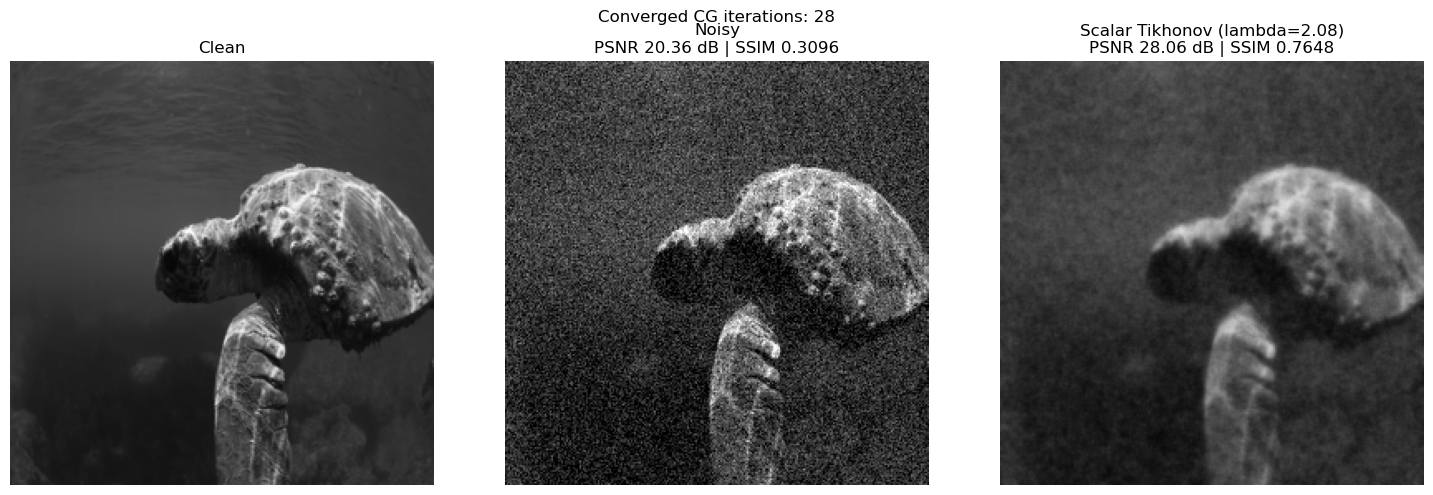

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/tikhonov/scalar_tikhonov_example.png


In [9]:
sample = val_loader.dataset[0]
clean = sample["clean"].unsqueeze(0).to(device)
noisy = sample["noisy"].unsqueeze(0).to(device)
reconstruction, cg_info = scalar_tikhonov_denoise(
    noisy, lam=best_lambda, max_iter=CG_MAX_ITER, tol=CG_TOL
)
reconstruction = reconstruction.clamp(0.0, 1.0)

noisy_psnr = float(batch_psnr(noisy, clean)[0].item())
noisy_ssim = float(batch_ssim(noisy, clean)[0].item())
recon_psnr = float(batch_psnr(reconstruction, clean)[0].item())
recon_ssim = float(batch_ssim(reconstruction, clean)[0].item())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(clean[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Clean")
axes[1].imshow(noisy[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Noisy\nPSNR {noisy_psnr:.2f} dB | SSIM {noisy_ssim:.4f}")
axes[2].imshow(reconstruction[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
axes[2].set_title(
    f"Scalar Tikhonov (lambda={best_lambda:.4g})\n"
    f"PSNR {recon_psnr:.2f} dB | SSIM {recon_ssim:.4f}"
)
for axis in axes:
    axis.axis("off")
fig.suptitle(f"Converged CG iterations: {cg_info['num_iter']}")
fig.tight_layout()
example_path = results_dir / "scalar_tikhonov_example.png"
fig.savefig(example_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", example_path)
